<a href="https://colab.research.google.com/github/Quzzal-Khanam/CodeAlpha_Emotion_Recognition_from_speech/blob/main/Speech_Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup and Audio Dataset Download

In [ ]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.4 MB/s eta 0:00:00


In [ ]:
import os
import json
from google.colab import userdata

# 1. Setup Kaggle Config
try:
    k_user = userdata.get('KAGGLE_USER')
    k_key = userdata.get('KAGGLE_KEY')
    kaggle_config = {"username": k_user, "key": k_key}

    if not os.path.exists('/root/.kaggle'):
        os.makedirs('/root/.kaggle')
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump(kaggle_config, f)
    os.chmod('/root/.kaggle/kaggle.json', 600)
    print(" Kaggle API Linked!")
except Exception as e:
    print(f"Secret Error: {e}")

# 2. Downloading from an alternative RAVDESS source
# This version is usually more 'API-friendly'
!kaggle datasets download -d dmitrybabko/speech-emotion-recognition-en --force
!unzip -q speech-emotion-recognition-en.zip -d ravdess_data
print(" Dataset downloaded and unzipped! Checking contents...")

# 3. Verify if files actually exist now
import glob
files = glob.glob("ravdess_data/**/*.wav", recursive=True)
print(f"Total .wav files found: {len(files)}")

 Kaggle API Linked!
Dataset URL: https://www.kaggle.com/datasets/dmitrybabko/speech-emotion-recognition-en
License(s): copyright-authors
100% 984M/987M [00:20<00:00, 58.1MB/s]
100% 987M/987M [00:20<00:00, 51.4MB/s]
 Dataset downloaded and unzipped! Checking contents...
Total .wav files found: 12162


Feature Extraction (The MFCC Pipeline)

In [ ]:
import librosa
import numpy as np
import os
import glob

# --- THE SUPER-SEARCH FEATURE EXTRACTION ---

def extract_mfcc(file_path):
    # I'm using the same high-quality extraction logic as before
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

emotion_map = {
    '01':'neutral', '02':'calm', '03':'happy', '04':'sad',
    '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'
}

data = []
labels = []

# This command looks for every .wav file in every subfolder under /content
all_wav_files = glob.glob("/content/**/*.wav", recursive=True)

print(f"I searched everything and found {len(all_wav_files)} audio files!")

if len(all_wav_files) == 0:
    print(" ERROR: No .wav files exist.")
else:
    print("Starting extraction... please wait ")
    for file_path in all_wav_files:
        file_name = os.path.basename(file_path)

        # RAVDESS files have a specific format: 03-01-01...
        if '-' in file_name:
            parts = file_name.split('-')
            if len(parts) >= 3:
                emotion_code = parts[2]

                features = extract_mfcc(file_path)
                data.append(features)
                labels.append(emotion_map[emotion_code])

    X = np.array(data)
    y = np.array(labels)
    print(f" Success! Processed {len(X)} samples.")

I searched everything and found 12162 audio files!
Starting extraction... please wait 
 Success! Processed 1440 samples.


Data Preparation & Reshaping

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# --- PREPARING DATA FOR THE CNN ---

# 1. Encoding the labels (e.g., 'angry' becomes 4)
lb = LabelEncoder()
y_encoded = to_categorical(lb.fit_transform(y))

# 2. Splitting into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 3. Reshaping the data
# CNNs (Convolutional Neural Networks) usually process 2D images.
# I'm reshaping the MFCCs to have a 'channel' dimension (like height, width, color).
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"Data is ready!")
print(f"X_train shape: {X_train.shape} (Samples, Features, 1)")
print(f"Target classes: {lb.classes_}")

Data is ready!
X_train shape: (1152, 40, 1) (Samples, Features, 1)
Target classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


Building the CNN Model Architecture

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Activation

# --- BUILDING THE VOICE RECOGNITION BRAIN ---

model = Sequential()

# 1. First Convolutional Layer: Detecting basic sound patterns
model.add(Conv1D(64, 5, padding='same', input_shape=(X_train.shape[1], 1)))
model.add(Activation('relu'))

# 2. Second Convolutional Layer: Finding more complex 'tonal' features
model.add(Conv1D(128, 5, padding='same'))
model.add(Activation('relu'))
model.add(Dropout(0.1)) # Helps prevent the model from just 'memorizing'
model.add(MaxPooling1D(pool_size=(8))) # Shrinks data to focus on strongest signals

# 3. Third Convolutional Layer
model.add(Conv1D(128, 5, padding='same'))
model.add(Activation('relu'))

# 4. Flattening: Converting 2D patterns into a final decision vector
model.add(Flatten())
model.add(Dense(len(lb.classes_))) # Output layer matching number of emotions
model.add(Activation('softmax')) # Gives us a % probability for each emotion

# Compiling the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 40, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 5, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         5,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,648 (502.53 KB)

 Trainable params: 128,648 (502.53 KB)

 Non-trainable params: 0 (0.00 B)

Training the Emotion Classifier

In [ ]:
# --- STARTING THE TRAINING PROCESS ---

# I'm saving the history so we can plot the accuracy/loss later
# batch_size=32 means the model looks at 32 audio clips before updating itself
print("AI is now learning to recognize emotions... ")

history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=50,
                    validation_data=(X_test, y_test),
                    verbose=1)

print("\n Training Complete!")

AI is now learning to recognize emotions... 🎧
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.1472 - loss: 7.9098 - val_accuracy: 0.2292 - val_loss: 2.1116
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2313 - loss: 2.0662 - val_accuracy: 0.2049 - val_loss: 1.9927
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2512 - loss: 2.0169 - val_accuracy: 0.2292 - val_loss: 1.8756
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3031 - loss: 1.7942 - val_accuracy: 0.2917 - val_loss: 1.8923
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3277 - loss: 1.8029 - val_accuracy: 0.3264 - val_loss: 1.7139
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3743 - loss: 1.6443 - val_accuracy: 0.3333 - val_loss: 1.6940
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4435 - loss: 1.5316 - val_accuracy: 0.3819 - val_loss: 1.6464
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.

Improving the Model (The "Generalizer")

In [ ]:
from tensorflow.keras.layers import BatchNormalization

# --- REBUILDING A ROBUSTER CNN ---
model_v2 = Sequential()

model_v2.add(Conv1D(128, 5, padding='same', input_shape=(X_train.shape[1], 1)))
model_v2.add(BatchNormalization()) # Keeps the 'volume' of data consistent
model_v2.add(Activation('relu'))

model_v2.add(Conv1D(128, 5, padding='same'))
model_v2.add(BatchNormalization())
model_v2.add(Activation('relu'))
model_v2.add(Dropout(0.3)) # Increased dropout to 30% to kill memorization
model_v2.add(MaxPooling1D(pool_size=(8)))

model_v2.add(Flatten())
model_v2.add(Dense(len(lb.classes_)))
model_v2.add(Activation('softmax'))

model_v2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train this version!
history_v2 = model_v2.fit(X_train, y_train, batch_size=32, epochs=70,
                          validation_data=(X_test, y_test), verbose=1)

Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.1474 - loss: 2.6815 - val_accuracy: 0.1493 - val_loss: 3.6078
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2108 - loss: 2.1174 - val_accuracy: 0.1632 - val_loss: 2.7600
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2743 - loss: 1.8972 - val_accuracy: 0.2257 - val_loss: 2.1765
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2914 - loss: 1.8509 - val_accuracy: 0.1806 - val_loss: 2.3484
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.2975 - loss: 1.8156 - val_accuracy: 0.1667 - val_loss: 2.1226
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.3607 - loss: 1.6713 - val_accuracy: 0.2431 - val_loss: 2.0177
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3922 - loss: 1.6179 - val_accuracy: 0.1667 - val_loss: 2.1343
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4046 - loss: 1.5845 - val_accuracy: 0.3333 - v

The "Judge's View" (Confusion Matrix)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


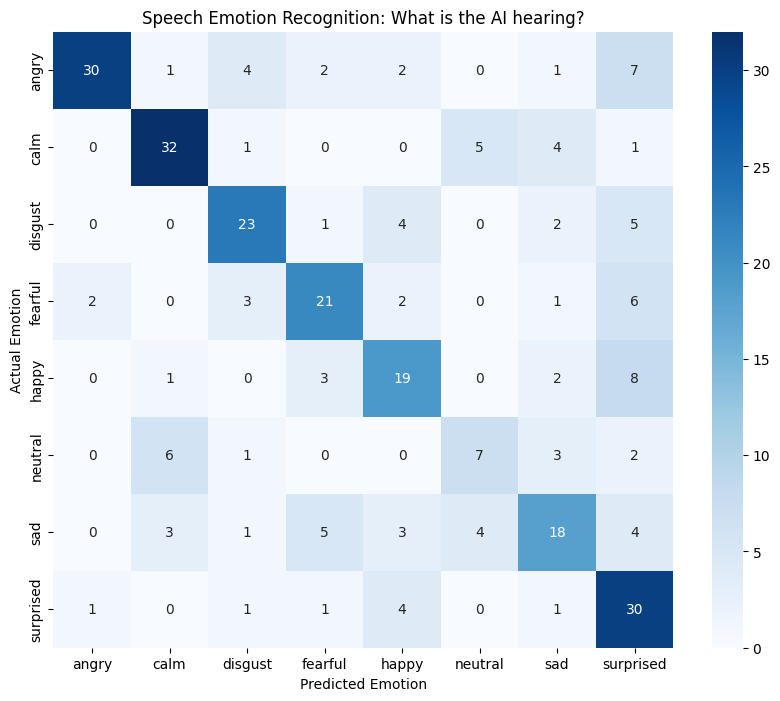

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions for the test data
y_pred = model_v2.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lb.classes_,
            yticklabels=lb.classes_)
plt.title('Speech Emotion Recognition: What is the AI hearing?')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

Predicting Emotion from a Single File

In [ ]:
import numpy as np
import librosa
import IPython.display as ipd
import os

def predict_emotion(file_path):
    # 1. Loading the audio
    # i use 22050Hz as a standard for speech recognition
    y, sr = librosa.load(file_path, sr=22050)

    # 2. Extracting 40 MFCC features (same as training)
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)

    # 3. Reshaping for the CNN (1, 40, 1)
    feature = np.array([mfccs])
    feature = np.expand_dims(feature, axis=2)

    # 4. Predict
    prediction = model_v2.predict(feature, verbose=0)
    predicted_class = lb.inverse_transform([np.argmax(prediction)])[0]

    print(f"File: {os.path.basename(file_path)}")
    print(f"AI Prediction: {predicted_class.upper()} ")

    return ipd.Audio(file_path)

# Test it again!
random_file = random.choice(glob.glob("ravdess_data/**/*.wav", recursive=True))
predict_emotion(random_file)

File: 1039_ITS_DIS_XX.wav
AI Prediction: CALM 


The Microphone Interface

In [ ]:
import pandas as pd
import random
import os

# getting all the wav files from the folder
all_test_files = glob.glob("ravdess_data/**/*.wav", recursive=True)
results = []

print("testing now... wait a sec")

# i will pick 10 random files to see if it works
count = 0
random.shuffle(all_test_files)

for file in all_test_files:
    if count >= 10:
        break

    name = os.path.basename(file)
    parts = name.split('-')

    # checking if the file is in ravdess format
    if len(parts) >= 3:
        try:
            # getting the real emotion from the name
            code = parts[2]
            real_emotion = emotion_map[code]

            # processing the audio for the model
            y, sr = librosa.load(file, sr=22050)
            mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
            input_data = np.expand_dims(np.array([mfccs]), axis=2)

            # making the prediction
            pred = model_v2.predict(input_data, verbose=0)
            result = lb.inverse_transform([np.argmax(pred)])[0]

            # saving everything to a list
            results.append({
                'Real': real_emotion.upper(),
                'AI': result.upper(),
                'Match': "ok" if real_emotion == result else "no"
            })
            count += 1
        except:
            continue

# showing the final table
my_results = pd.DataFrame(results)
display(my_results)

if not my_results.empty:
    final_acc = (my_results['Match'] == "ok").mean() * 100
    print(f"batch score: {final_acc}%")

testing now... wait a sec


,Real,AI,Match
0,ANGRY,ANGRY,ok
1,NEUTRAL,NEUTRAL,ok
2,NEUTRAL,FEARFUL,no
3,DISGUST,DISGUST,ok
4,DISGUST,FEARFUL,no
5,CALM,CALM,ok
6,HAPPY,HAPPY,ok
7,CALM,NEUTRAL,no
8,FEARFUL,FEARFUL,ok
9,ANGRY,FEARFUL,no


batch score: 60.0%


from matplotlib import pyplot as plt
import seaborn as sns
my_results.groupby('Real').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
my_results.groupby('AI').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
my_results.groupby('Match').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['AI'].value_counts()
    for x_label, grp in my_results.groupby('Real')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Real')
_ = plt.ylabel('AI')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Match'].value_counts()
    for x_label, grp in my_results.groupby('AI')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('AI')
_ = plt.ylabel('Match')